# Credit Risk on Freddie Mac 2019: From 90+ DPD Risk to Portfolio Value

Théophile Jennepin · [GitHub](https://github.com/capristunt) · [Qaventra Data](https://qaventra-data.com)

A mortgage lender loses money in two ways: holding loans that go bad, and turning away loans that would have paid. This case study measures how much a calibrated risk score helps balance the two, on 49,946 loans from the 2019 vintage acquired by Freddie Mac. A logistic regression matched a LightGBM challenger on accuracy while staying fully auditable. Applied at a break-even PD of 10.7%, fixed from margin and loss assumptions rather than fitted, it keeps 93.5% of test loans and adds \\$2.7M of scenario value on \\$3.84B of balance (95% interval: \\$1.1M to \\$4.4M). The gain concentrates where policies are selective: against FICO floors that keep 96% of loans or fewer, the score wins at every tested cutoff.

1. [The business problem](#business-problem)
2. [The data](#data)
3. [What the portfolio looks like](#portfolio)
4. [The model, in plain language](#model)
5. [From probability to decision](#decision)
6. [What a lender should do differently](#recommendations)
7. [Limits and next steps](#limits)

In [1]:
from pathlib import Path
from IPython.display import Image, display

cwd = Path.cwd().resolve()
if (cwd / "pyproject.toml").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not resolve project root from {cwd}")

FIGURES_DIR = PROJECT_ROOT / "figures"

REQUIRED_FIGURES = [
    "02_bivariate_fico_ltv.png",
    "03_logistic_coefs_fico_ltv_dti.png",
    "03_reliability_diagram.png",
    "03_cutoff_tradeoff.png",
]
missing = [f for f in REQUIRED_FIGURES if not (FIGURES_DIR / f).exists()]
assert not missing, f"Missing figures, rerun notebooks 02 and 03: {missing}"


FIGURE_ALT = {
    "02_bivariate_fico_ltv.png":
        "Heatmap of recorded 90-plus-DPD rates by FICO and LTV bands.",
    "03_logistic_coefs_fico_ltv_dti.png":
        "Reference-coded logistic coefficients for FICO, LTV and DTI bands.",
    "03_reliability_diagram.png":
        "Test reliability curves and score distributions for raw and isotonic logistic predictions.",
    "03_cutoff_tradeoff.png":
        "Training cutoff sensitivity and frozen-policy scenario values on the test set.",
}


def show_figure(name: str, width: int = 900) -> None:
    """Embed an accessible PNG so the exported HTML is self-contained."""
    display(Image(
        filename=str(FIGURES_DIR / name),
        width=width,
        alt=FIGURE_ALT[name],
    ))

<a id="business-problem"></a>
## 1. The business problem

An investor choosing among already-originated mortgages faces an asymmetric decision: a safe loan that is not acquired forfeits its margin, while a loan that becomes seriously delinquent can lose a share of its balance. In the illustrative scenario used here, a performing loan earns 1.5% of balance per year and a loan reaching 90 or more days past due is assigned a 25% loss severity. Over two years, one such adverse event offsets the margin from roughly eight performing loans.

This asymmetry changes the question. The objective is not merely to rank risky borrowers, but to identify which loans are worth holding under explicit margin and loss assumptions. Section 5 translates the model's estimated probability of a recorded 90+ DPD event into a break-even threshold.

The population defines what can be claimed. Every observation is a loan that was originated and acquired by Freddie Mac; rejected applications are absent. The analysis therefore evaluates portfolio selection or review **within an acquired, GSE-eligible book**. Extending the result to application approval would require data on accepted and rejected applicants.

The loans were originated before the pandemic, but their two-year performance windows extend through 2020 and 2021. The outcome therefore reflects both borrower characteristics at origination and the environment encountered afterwards.


<a id="data"></a>
## 2. The data

The analysis uses Freddie Mac's Single-Family Loan-Level Dataset (SFLLD), which pairs an origination record with monthly performance history. The study population is the 2019 vintage of the sample release: 49,946 loans with first payments between February 2019 and March 2020, totalling \\$12.7B of original balance across 54 US jurisdictions—the 50 states, the District of Columbia, Guam, Puerto Rico and the US Virgin Islands.

The outcome is whether a loan reaches 90 or more days past due at least once in its first 24 months. A fixed window gives earlier and later loans the same observation horizon. In total, 2,292 loans, or 4.59%, record that event. Throughout this case study, the estimated **90+ DPD probability is used as a default-risk proxy**. It is not a charge-off probability or realised-loss measure: a loan may become 90 days late and later cure.

Predictors are limited to information assumed available before pricing: credit score, loan-to-value, debt-to-income, loan purpose, occupancy, channel, property type, number of units and borrowers, first-time buyer status and census region. Interest rate is excluded because it is set during pricing—which the score is meant to inform—and may already encode the originator's own assessment of risk.


<a id="portfolio"></a>
## 3. What the portfolio looks like

This is a prime book. Purchase loans account for 55.6% of volume, almost two thirds of borrowers score 740 or above, and fewer than 4% score below 660. Any value added by a risk score will therefore come from distinguishing a relatively thin risk tail rather than reshaping the whole portfolio.

Three origination attributes carry most of the observed variation in the recorded 90+ DPD rate. These are unadjusted comparisons: each rate combines the attribute's association with everything correlated with it.

**Credit score** has the steepest gradient. The event rate falls from 12.0% for scores between 620 and 659 to 1.7% at 780 and above, a factor of seven.

**Loan-to-value** moves in the expected direction, more gently: 2.9% at 60% LTV or below and 7.8% above 95%.

**Debt-to-income** rises from 2.3% below 30% to 7.9% in the 43–45% band, then falls to 6.4% above 45%. This univariate reversal should not be read as evidence that heavier debt loads are protective. Section 4 shows that the decline is not reproduced after adjustment for the other model features.

The grid below crosses FICO and LTV. “Default rate” in the saved chart means the frequency of a recorded 90+ DPD event.


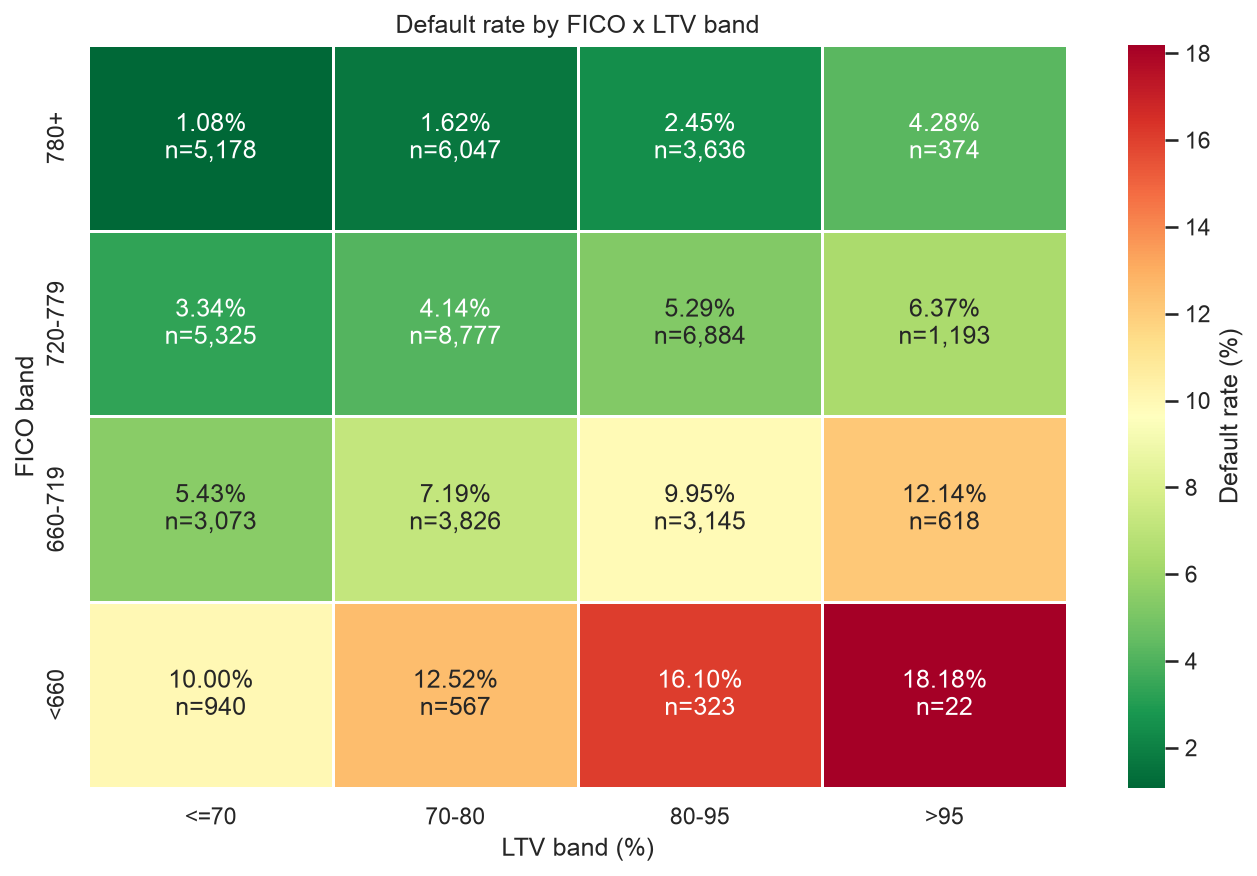

In [2]:
show_figure("02_bivariate_fico_ltv.png", width=750)

Risk rises along both axes in every row and column, so neither dimension can be read alone. The corners make the point. Borrowers scoring below 660 with LTV of 70% or less record an event rate of 10.0%, more than twice the 4.3% observed among borrowers scoring 780 or above with LTV over 95%. Collateral cushions risk; it does not substitute for credit quality. The most extreme cell—FICO below 660 and LTV above 95%—contains only 22 loans and is left uninterpreted.


<a id="model"></a>
## 4. The model, in plain language

Two models were built. The first is a logistic regression on banded attributes: each FICO, LTV and DTI band is measured against an explicit reference, together with low-cardinality borrower, property and loan characteristics. It also includes one targeted flag for purchase loans combining a first-time buyer with LTV above 80%. The second is a LightGBM challenger using raw FICO, LTV, DTI and loan balance plus the same categorical information, allowing flexible non-linearities and interactions.

The selection rule was fixed before evaluating the test set: LightGBM would replace the logistic model only if it improved cross-validated training AUC by at least 0.005. Its OOF improvement was 0.0023, so the logistic model was retained. The untouched test set shows no evidence of a material discrimination loss from that choice.

| Model | AUC | PR-AUC | KS | Brier |
|---|---:|---:|---:|---:|
| Logistic — selected | 0.732 | 0.113 | 0.346 | 0.0424 |
| LightGBM | 0.726 | 0.117 | 0.328 | 0.0423 |

The event prevalence is 4.59%, so the logistic PR-AUC of 0.113 is roughly 2.5 times the no-skill baseline. For AUC, the paired difference `LightGBM − logistic` is −0.006 with a 95% bootstrap interval of [−0.015, +0.003], which is not distinguishable from zero. In this sample, the logistic model's auditability therefore comes without a detectable AUC penalty.


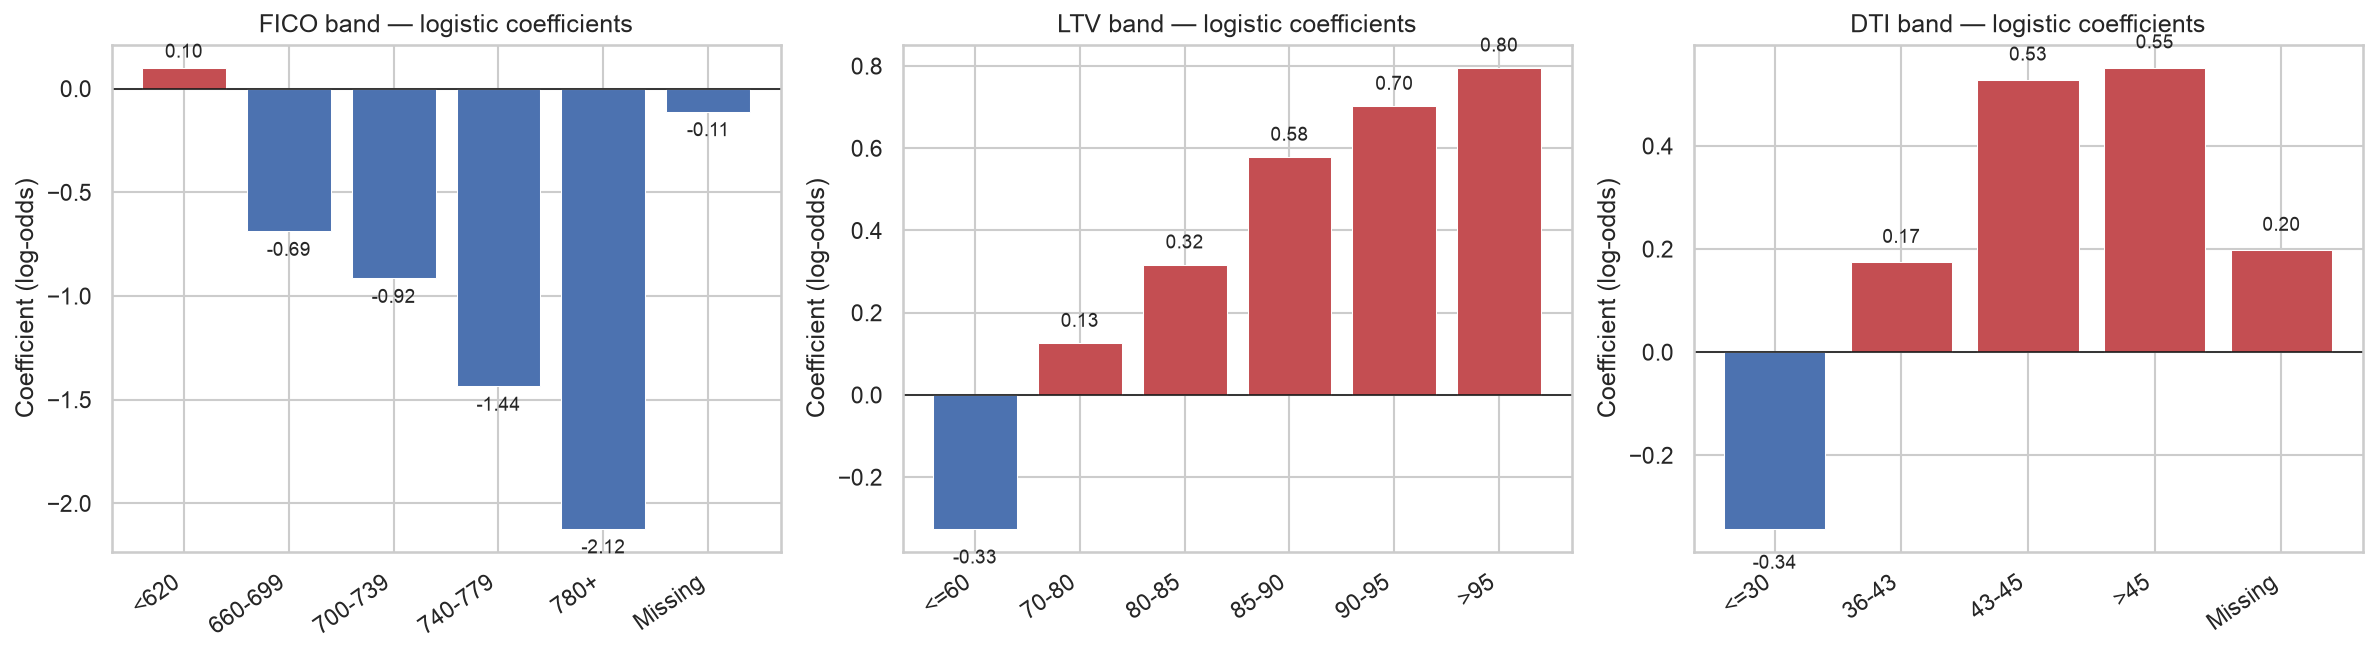

In [3]:
show_figure("03_logistic_coefs_fico_ltv_dti.png")

The omitted reference bands have coefficient zero: FICO 620–659, LTV 60–70 and DTI 30–36. Every displayed coefficient is a conditional log-odds difference relative to that reference, with the other included variables fixed; it is an association, not a causal effect.

The pattern is clear when translated into odds. Relative to FICO 620–659, FICO 780 or above is associated with about 88% lower odds of a recorded 90+ DPD event. LTV above 95% is associated with a little more than twice the odds observed at LTV 60–70, with much of the increase building above 80%. The sub-620 band contains only 36 loans in the full sample and 22 in the training sample, so its coefficient is not interpreted.

DTI is the instructive case. The adjusted model does not reproduce the apparent decline above 45: the coefficients for 43–45 and above 45 are nearly identical (+0.53 and +0.55). The univariate reversal is therefore more consistent with portfolio composition or sampling noise than with a stable protective effect. The LightGBM diagnostics in notebook 03 provide a non-linear consistency check, not evidence of causal effects or proof about the selected logistic model.


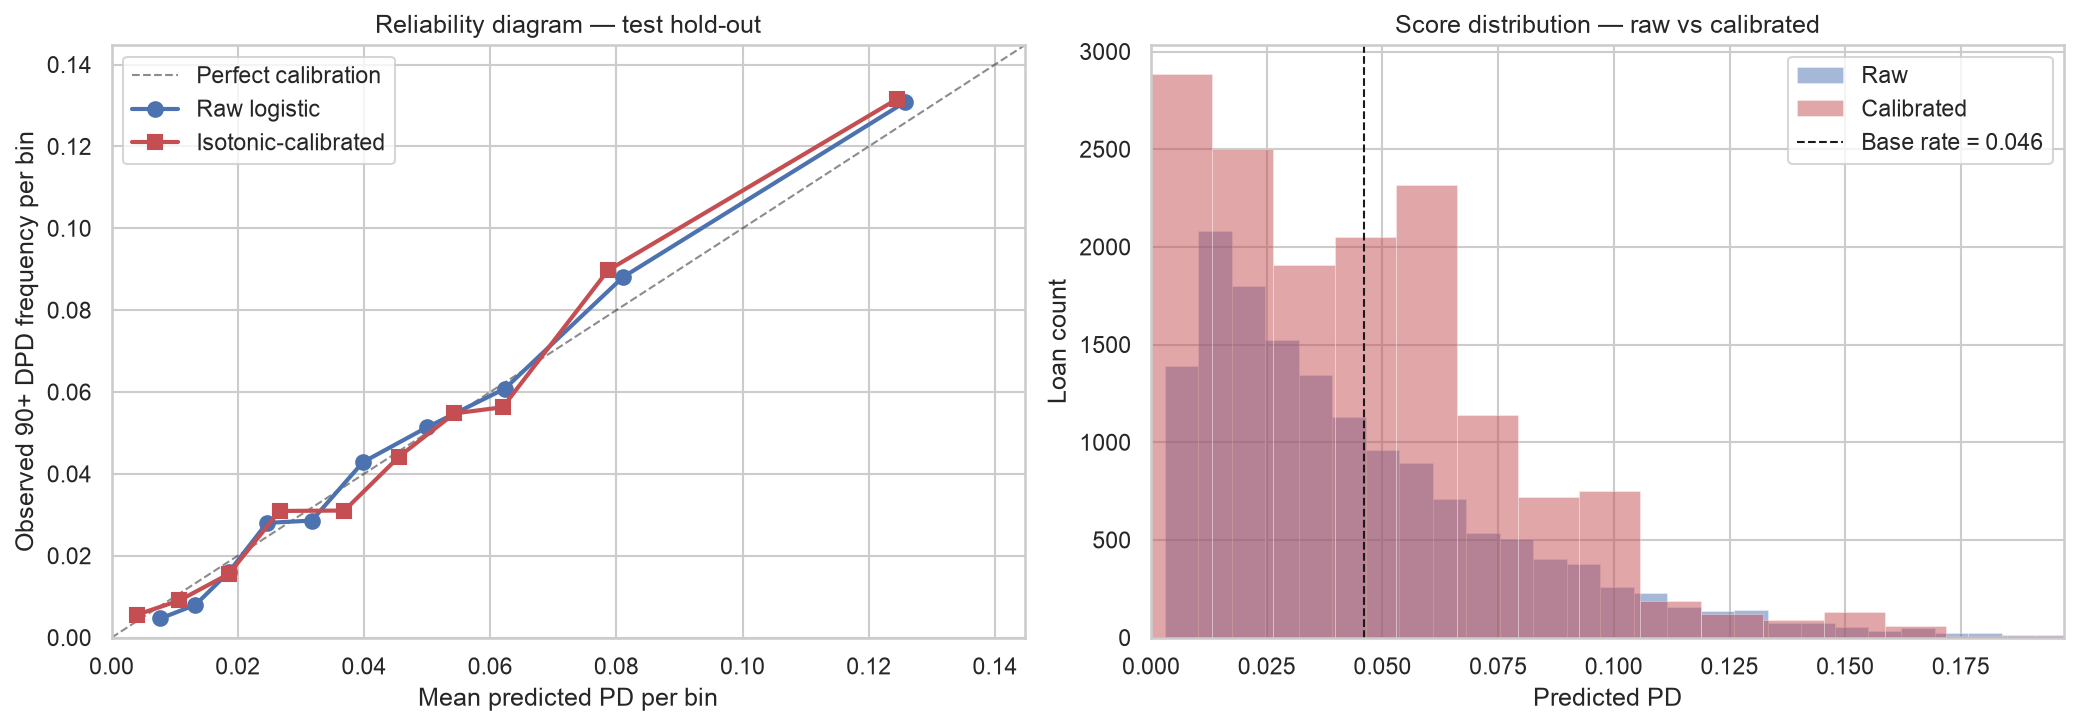

In [4]:
show_figure("03_reliability_diagram.png")

A score used for decisions must also be calibrated: loans assigned an 8% probability should record the event at roughly that frequency over repeated samples. The raw logistic model shows acceptable calibration on the held-out test set. Its mean predicted probability is 4.55% against an observed rate of 4.59%, and predicted and observed rates track one another across ten quantile groups (quantile ECE 0.0035).

The raw logistic is the selected model in the figure above; isotonic calibration is shown only as a rejected challenger. It was evaluated through nested cross-validation and not retained because OOF Brier worsened slightly, from 0.042517 to 0.042574.

The chronological sensitivity check is less reassuring. Refitting the same specification on loans with first payments through September 2019 and scoring later cohorts produces an AUC of 0.715 and underpredicts their event rate: 4.16% predicted against 4.65% observed. The model remains directionally informative within the vintage, but its performance weakens and it has not yet been validated on a later origination vintage.


<a id="decision"></a>
## 5. From probability to decision

A probability becomes a selection rule once it is combined with economics. The scenario assigns a two-year margin of 3% of balance to a performing loan and a 25% loss severity to a loan reaching 90+ DPD. A loan has positive expected scenario value while expected margin exceeds expected loss:

$$(1 - PD_{90+}) \times 2m \;>\; PD_{90+} \times LGD
\quad\Longleftrightarrow\quad
PD_{90+} \;<\; PD^* = \frac{2m}{2m + LGD}
= \frac{0.03}{0.28} \approx 10.7\%$$

The threshold follows from the stated assumptions rather than realised test outcomes, so it was fixed before the test loans were evaluated.

Applied to 14,984 test loans representing \\$3.84B of balance, the rule selects 93.5%. The selected book records a 90+ DPD rate of 3.94%, against 4.59% for the full test set. Scenario value rises from \\$61.3M to \\$64.1M: a lift of \\$2.7M, or about 7 basis points of balance, with a paired 95% bootstrap interval of [\\$1.1M, \\$4.4M]. These dollar values are conditional on the assumed margin and LGD; they are not realised accounting profit.

The benchmark is a FICO floor selected on training data. The best candidate there, FICO 660 or above, does not improve test scenario value relative to selecting every loan (\\$61.1M versus \\$61.3M). A one-variable floor removes some loans that remain attractive under the scenario and retains others whose leverage, debt load or borrower structure raises their combined risk.


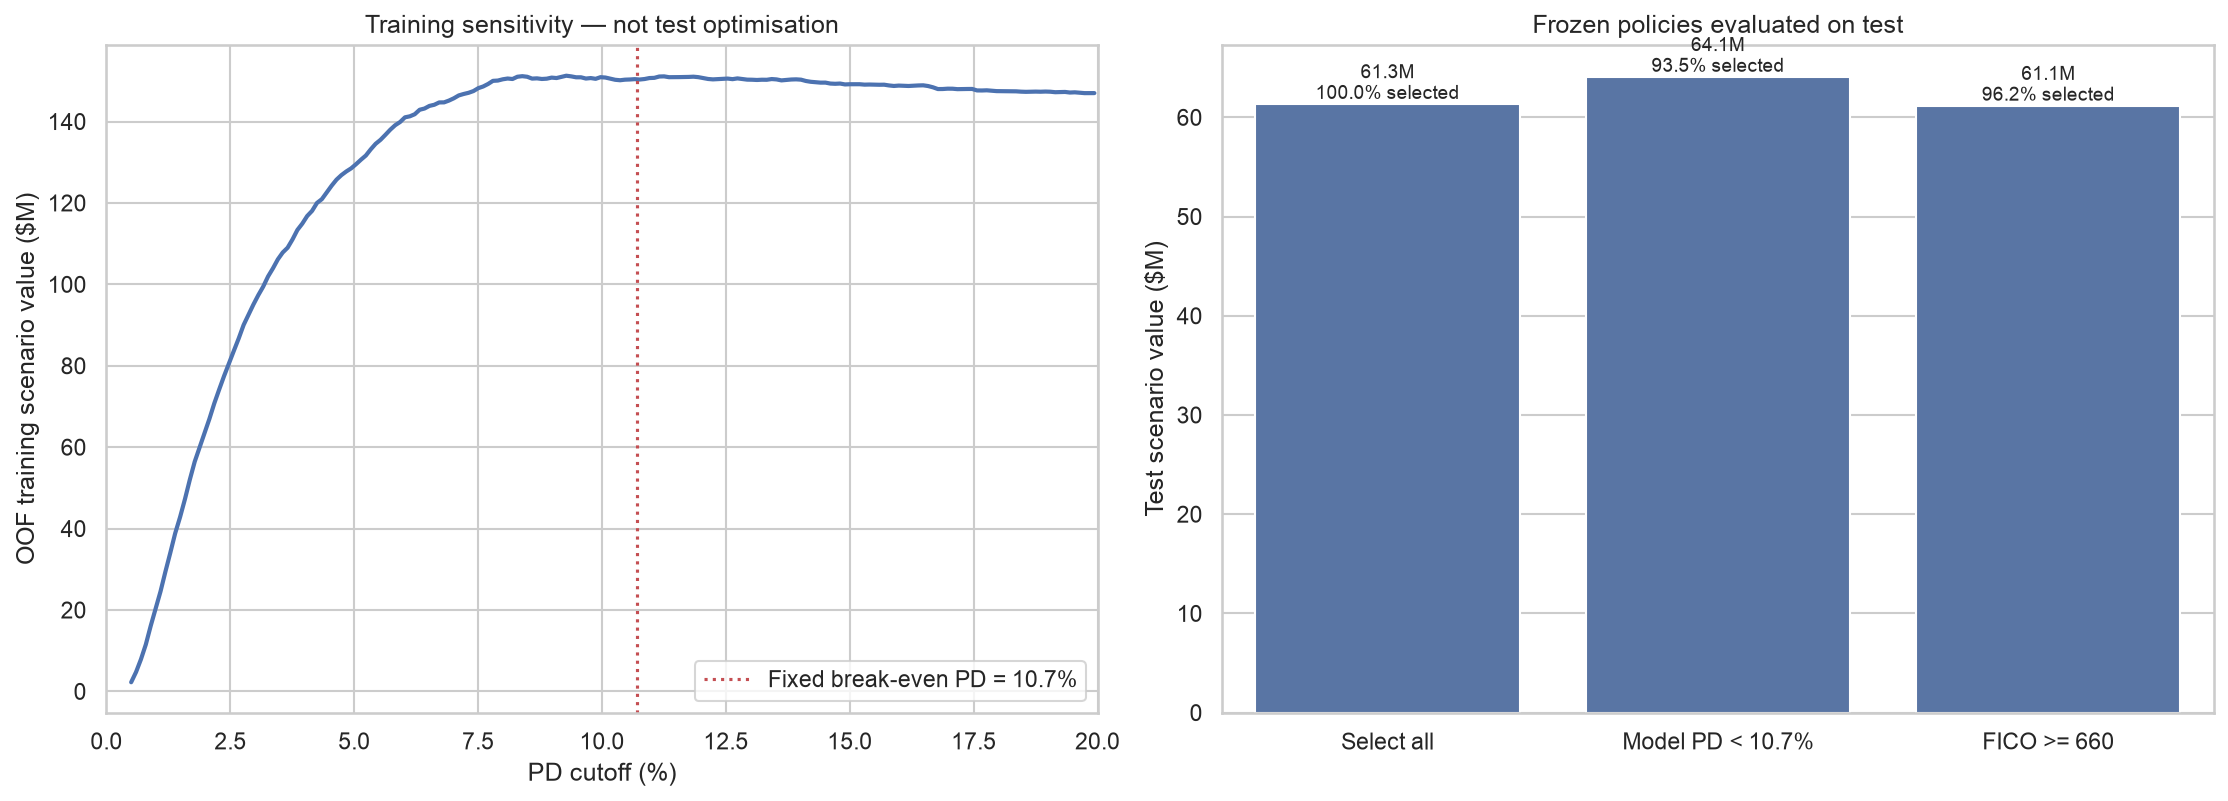

In [5]:
show_figure("03_cutoff_tradeoff.png")

The left panel is a training-only sensitivity diagnostic: it shows scenario value across PD cutoffs on OOF predictions. The fixed break-even threshold sits in a relatively flat area, so the training result is not highly sensitive to small movements around 10.7%. The right panel evaluates the three frozen policies once on the test set. Their total values are deliberately shown on a common zero-based scale: selecting this prime book more carefully adds about 4% to scenario value, not a multiple of it.

A fairer comparison gives the score and each FICO floor similar selectivity without tuning on test outcomes. For every prespecified FICO cutoff, its selection rate is measured on training data; an OOF score threshold is chosen to match that rate, and both frozen rules are then applied to the test set.

| FICO cutoff | Share selected on train | Model lift over FICO on test | 95% interval |
|---:|---:|---:|---:|
| 600 | 99.96% | +\\$0.06M | −\\$0.03M to +\\$0.15M |
| 620 | 99.91% | +\\$0.12M | −\\$0.02M to +\\$0.31M |
| 640 | 98.67% | +\\$0.76M | −\\$0.12M to +\\$1.68M |
| 660 | 96.29% | +\\$1.90M | +\\$0.69M to +\\$3.02M |
| 680 | 92.32% | +\\$3.50M | +\\$1.80M to +\\$5.28M |
| 700 | 84.88% | +\\$3.30M | +\\$1.16M to +\\$5.43M |
| 720 | 74.67% | +\\$4.03M | +\\$1.54M to +\\$6.22M |
| 740 | 62.69% | +\\$4.00M | +\\$1.59M to +\\$5.93M |

At selection rates near 100%, the two approaches cannot be distinguished. From the FICO 660 comparison onward, the model has positive scenario-value lift and each paired interval remains above zero under the stated margin and LGD assumptions. The value of combining multiple attributes is therefore most visible when portfolio selection becomes tighter.


<a id="recommendations"></a>
## 6. What a lender or investor should do differently

Three changes follow from the results. They apply to selecting or reviewing loans within a portfolio like the observed Freddie Mac book; extending them to application approval requires accepted-and-rejected applicant data.

**1. Tie the threshold to explicit economics.** The 10.7% threshold follows from margin and LGD assumptions owned by the finance and risk functions. It needs no optimisation on the test set, can be explained to a credit committee, and moves transparently when the assumptions change. Under the present scenario it adds \\$2.7M, about 7 basis points of test balance, relative to selecting every loan; the FICO floor chosen on training data does not improve that baseline on test.

**2. Use the multivariate score where selectivity matters.** At policies retaining approximately 99% or more of loans, the score and a FICO floor are empirically indistinguishable. Under tighter matched-selection policies, the score produces \\$1.9M to \\$4.0M more test scenario value than the corresponding FICO rule. This is the range where combining credit quality, leverage, debt load and borrower structure adds the clearest value.

**3. Monitor calibration as outcomes mature and revalidate by vintage.** The chronological check already shows underprediction for later cohorts—4.16% predicted versus 4.65% observed. Mean predicted probability and observed 90+ DPD frequency should be compared for each cohort once enough of its 24-month window has matured. Before deployment on a new vintage, the frozen model and threshold should be validated; recalibration or refitting should use the most recent fully observed vintages rather than incomplete outcomes.


<a id="limits"></a>
## 7. Limits and next steps

**Selected population.** Every loan in the data was originated and acquired; rejected applications are unobserved. The results describe selection within an acquired book and cannot estimate the risk or profitability of applicants who were declined.

**Endpoint, not realised loss.** The label is a recorded 90+ DPD event and some affected loans later cure. Without borrower-assistance fields, assisted and non-assisted delinquency paths cannot be separated, and any pandemic-era distortion of the recorded endpoint cannot be signed or quantified.

**One vintage.** The model was evaluated on a random hold-out and on later cohorts of the same vintage, where performance was weaker (AUC 0.715). Neither is a genuine out-of-time validation on a later origination vintage.

**Assumed economics.** The 25% LGD and 1.5% annual margin are flat scenario assumptions. Bootstrap intervals capture sampling uncertainty conditional on this dataset and policy; they do not incorporate uncertainty in LGD, margin or the macroeconomic environment.

**Thin bands.** The sub-620 FICO band contains 36 loans in the full sample and only 22 in the model's training sample. A multi-vintage model should merge or regularise such sparse segments and report uncertainty around band effects.

The next steps follow directly: validate the frozen model on later origination vintages; add only macroeconomic variables observable at scoring time or supplied as explicit forecast scenarios; estimate LGD from actual loss and recovery data; and incorporate assistance-status fields to distinguish assisted from non-assisted delinquency paths. Application-level underwriting claims would additionally require accepted and rejected applications and a design that addresses sample-selection bias.
